# <div dir = 'rtl'>تمرین دوم سینا ملاابراهیمی</div>

# <div dir = 'rtl'>کتابخانه های لازم </div>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
import torch.nn.functional as F
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


# <div dir = 'rtl'>تولید داده ها </div>

In [ ]:

X, y = make_classification(
    n_samples=3500,
    n_features=2,
    n_redundant = 0,
    n_informative=2,
    n_classes=2,
    n_clusters_per_class=2,
    class_sep=1,          
    flip_y=0.15,            
    random_state=42
)

In [3]:
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype= torch.float32)

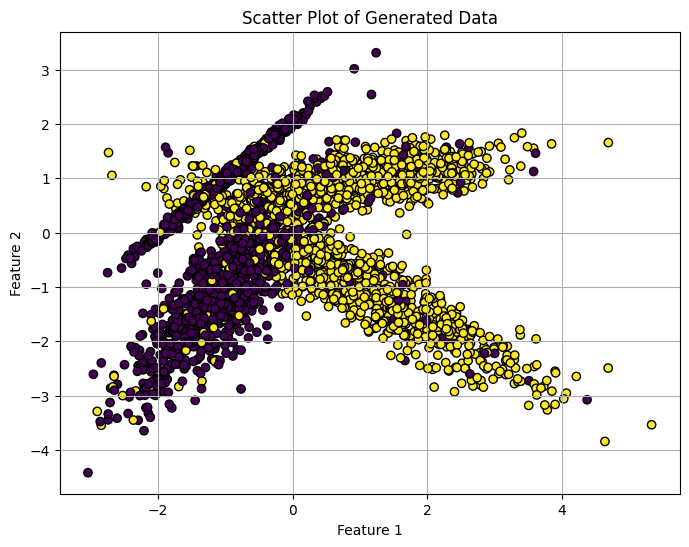

In [4]:
plt.figure(figsize=(8,6))
plt.scatter(X[:,0],X[:,1],c= y, cmap='viridis',edgecolors='k')
plt.title("Scatter Plot of Generated Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

# <div dir = 'rtl'>تعریف کلاس برای ساخت مدل</div>

In [5]:
class DynamicNet(nn.Module):
    def __init__(self, num_layers, num_neurons, input_dim, activation="relu", dropout_rate=0.0):
        super().__init__()
        layers = []
        activations = {
            "relu": nn.ReLU(),
            "tanh": nn.Tanh(),
            "sigmoid": nn.Sigmoid(),
            "leakyrelu": nn.LeakyReLU(0.01)
        }
        if activation.lower() not in activations:
            raise ValueError("Unsupported activation")
        act = activations[activation.lower()]
        current_dim = input_dim
        for _ in range(num_layers):
            layers.append(nn.Linear(current_dim,num_neurons))
            layers.append(act)
            if dropout_rate > 0.0:
                layers.append(nn.Dropout(p=dropout_rate))
            current_dim = num_neurons
        layers.append(nn.Linear(num_neurons,1))
        self.network = nn.Sequential(*layers)
    def forward(self, x):
        return self.network(x)

# <div dir = 'rtl'>بررسی تاثیر عمق و عرض شبكه و تحلیل پیچیدگی مدل از طريق رسم مرز تصميم	</div>

In [6]:
configs = [(1, 2), (1, 16), (4, 4), (4, 16), (8, 128)]
epochs = 300
lr = 0.001
x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [7]:
configs = [
    (1, 2),
    (1, 16),
    (4, 4),
    (4, 16),
    (8, 128)
]

criterion = nn.BCEWithLogitsLoss()

all_train_losses = {}
all_test_losses = {}
all_test_acc = {}
trained_models = {}

device = torch.device("cpu")
Xtr = x_train.to(device)
ytr = y_train.view(-1, 1).to(device)
Xte = x_test.to(device)
yte = y_test.view(-1, 1).to(device)

for num_layers, num_neurons in configs:
    name = f"{num_layers}x{num_neurons}"
    print(f"Training {name}...")

    model = DynamicNet(num_layers, num_neurons, input_dim=Xtr.shape[1]).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        logits = model(Xtr)
        loss = criterion(logits, ytr)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            test_logits = model(Xte)
            test_loss = criterion(test_logits, yte)
            test_losses.append(test_loss.item())

    all_train_losses[name] = train_losses
    all_test_losses[name] = test_losses

    with torch.no_grad():
        probs = torch.sigmoid(model(Xte))
        preds = (probs > 0.5).float()
        acc = (preds == yte).float().mean().item()

    all_test_acc[name] = acc
    trained_models[name] = model

    print(f"Model {name} -> Test Accuracy: {acc:.4f}")

Training 1x2...
Model 1x2 -> Test Accuracy: 0.4957
Training 1x16...
Model 1x16 -> Test Accuracy: 0.8243
Training 4x4...
Model 4x4 -> Test Accuracy: 0.8071
Training 4x16...
Model 4x16 -> Test Accuracy: 0.8386
Training 8x128...
Model 8x128 -> Test Accuracy: 0.8743


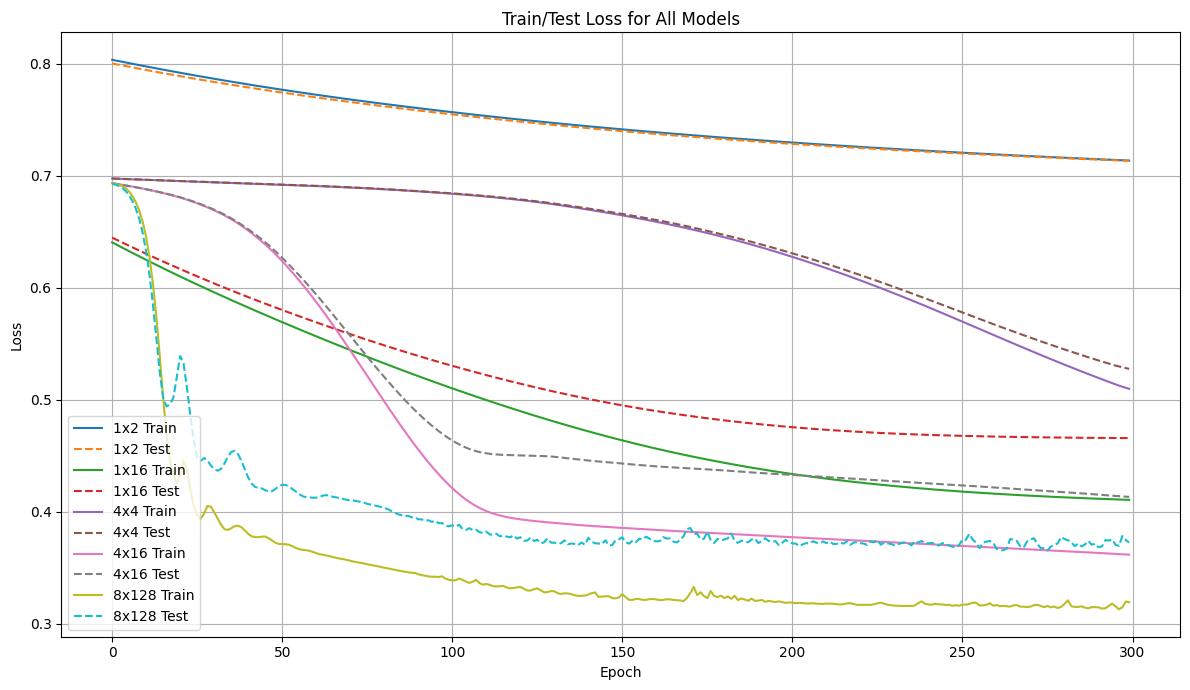

In [8]:
plt.figure(figsize=(12, 7))

for name in all_train_losses:
    plt.plot(all_train_losses[name], label=f"{name} Train")
    plt.plot(all_test_losses[name], linestyle="--", label=f"{name} Test")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train/Test Loss for All Models")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


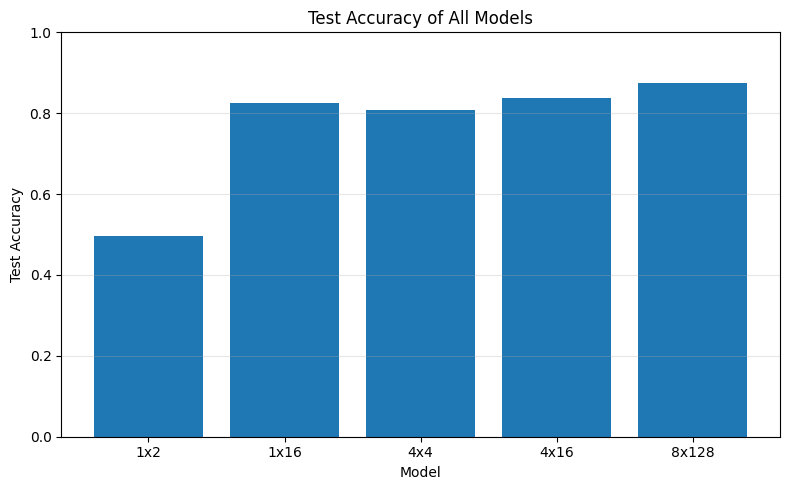

In [9]:
model_names = list(all_test_acc.keys())
acc_values = [all_test_acc[name] for name in model_names]

plt.figure(figsize=(8, 5))
plt.bar(model_names, acc_values)
plt.ylim(0, 1)
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy of All Models")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [10]:
def plot_decision_boundary(model, X, y, title, device="cpu", alpha=0.35):
    model.eval()

    X_np = X.cpu().numpy()
    y_np = y.cpu().numpy().reshape(-1)

    x_min, x_max = X_np[:, 0].min() - 0.5, X_np[:, 0].max() + 0.5
    y_min, y_max = X_np[:, 1].min() - 0.5, X_np[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.tensor(grid, dtype=torch.float32).to(device)

    with torch.no_grad():
        logits = model(grid_tensor)
        probs = torch.sigmoid(logits).cpu().numpy().reshape(xx.shape)
        Z = (probs >= 0.5).astype(int)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=alpha, cmap=plt.cm.coolwarm)
    plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, cmap=plt.cm.coolwarm, edgecolor="k", s=30)
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.tight_layout()
    plt.show()


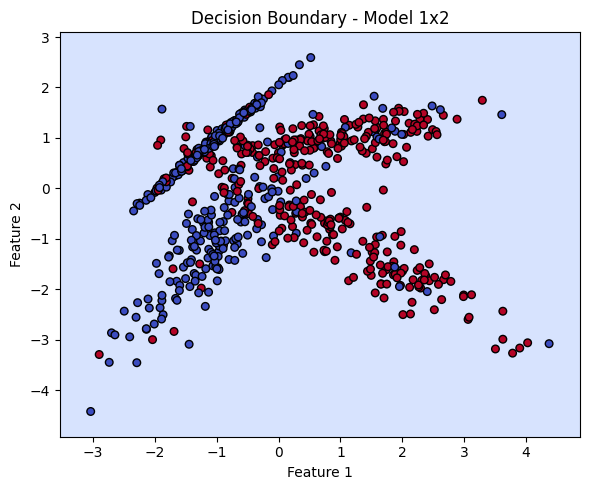

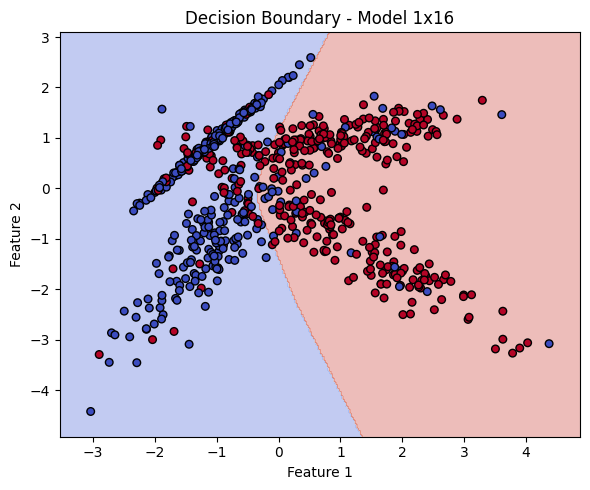

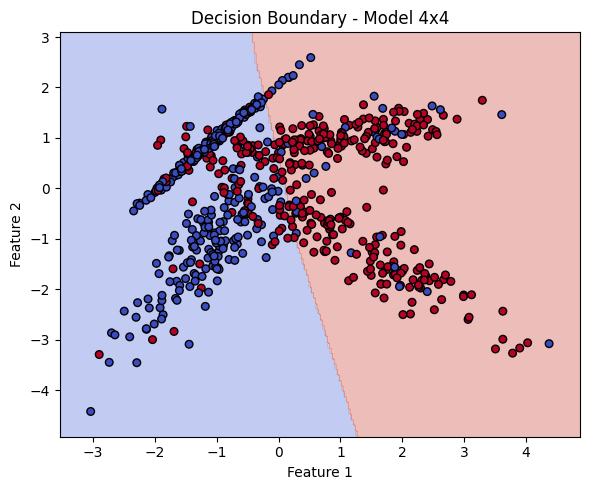

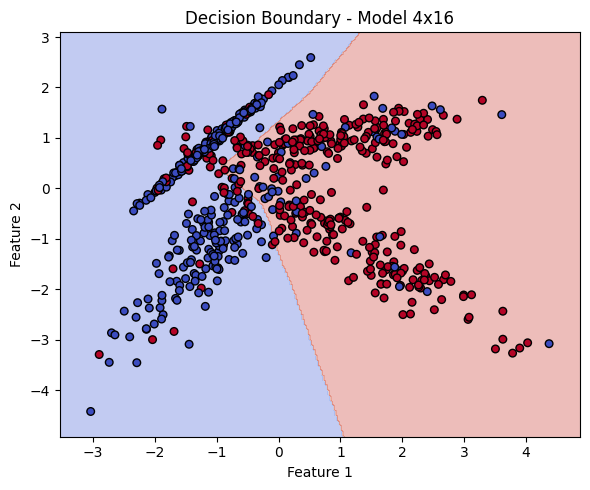

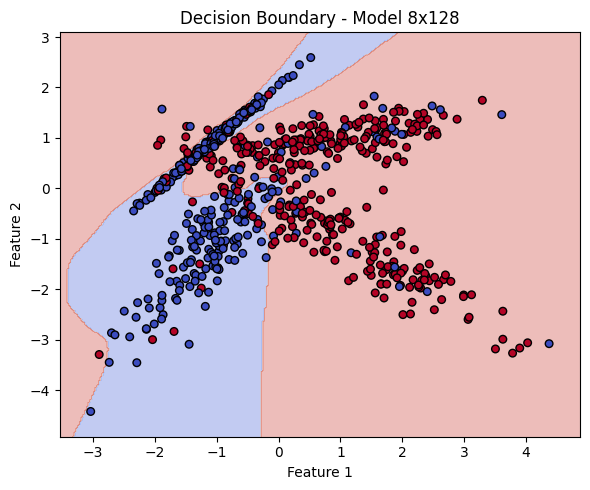

In [11]:
for name, model in trained_models.items():
    plot_decision_boundary(
        model=model,
        X=Xte,
        y=yte,
        title=f"Decision Boundary - Model {name}",
        device=device,
        alpha=0.35
    )


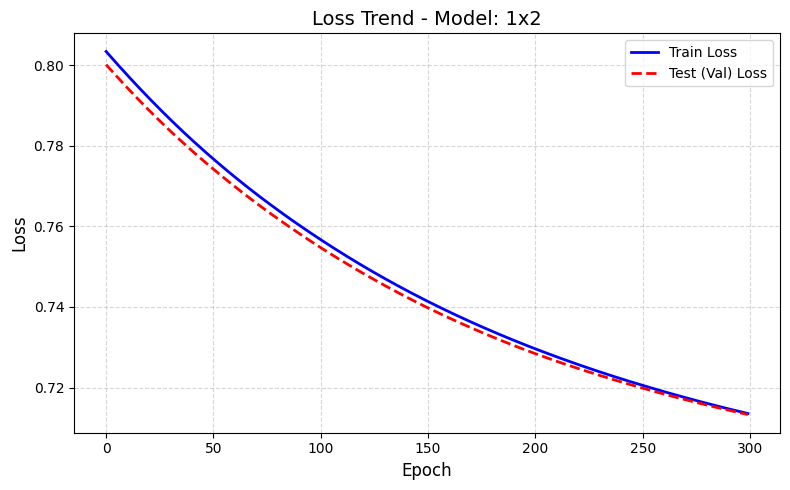

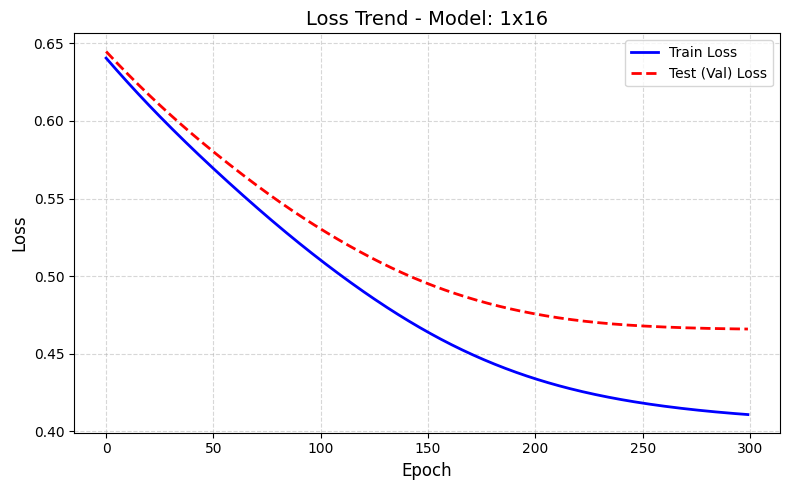

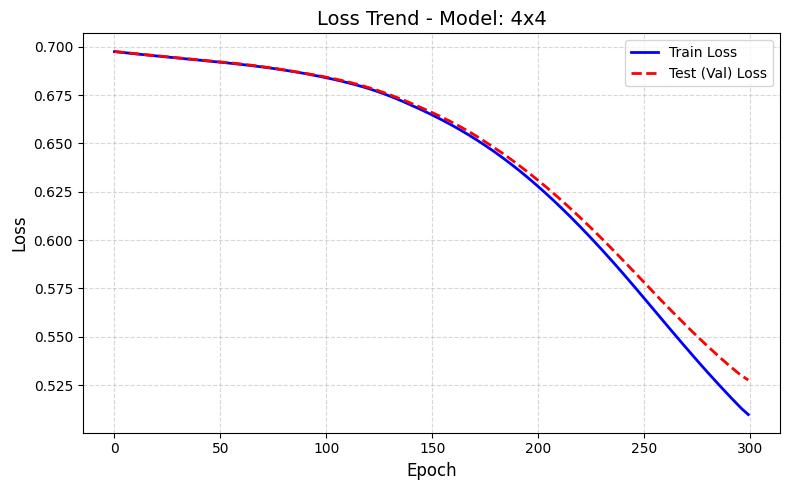

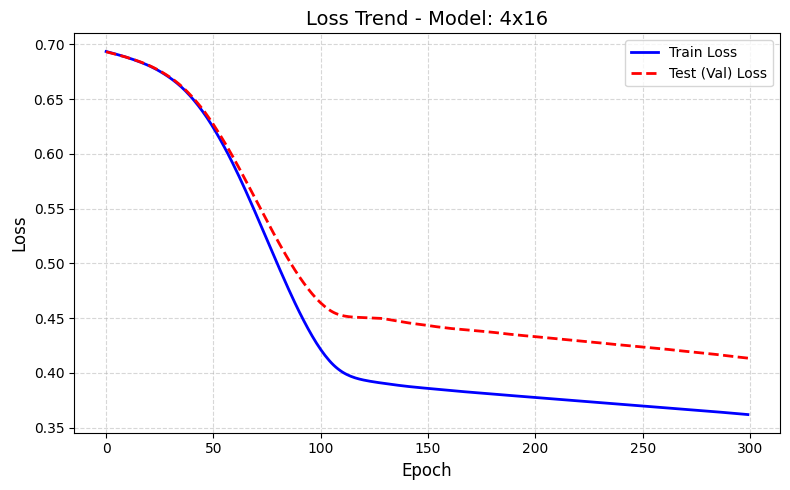

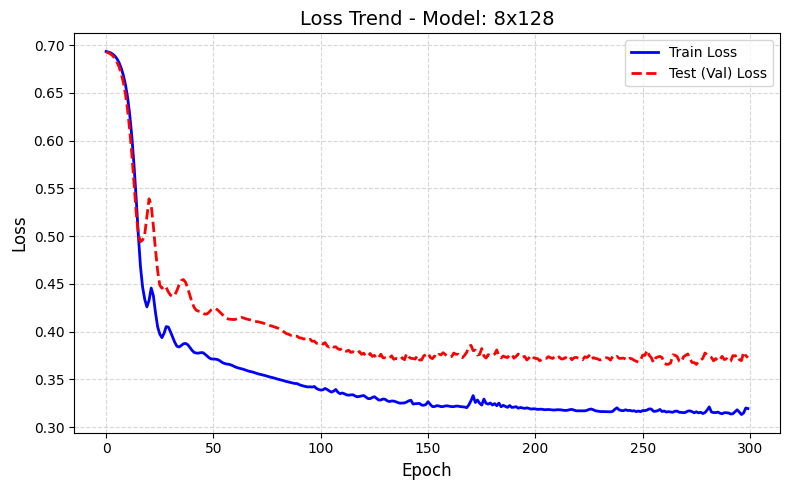

In [12]:
for name in all_train_losses.keys():
    plt.figure(figsize=(8, 5))
    
    plt.plot(all_train_losses[name], label='Train Loss', color='blue', linewidth=2)
    
    plt.plot(all_test_losses[name], label='Test (Val) Loss', color='red', linestyle='--', linewidth=2)
    
    plt.title(f"Loss Trend - Model: {name}", fontsize=14)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Loss", fontsize=12)
    plt.legend()
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()


# <div dir = 'rtl'>برآورد بایاس واریانس مدل </div>

In [ ]:
def train_model_for_bootstrap(model, train_loader, epochs=50, lr=0.001):
    criterion = nn.BCEWithLogitsLoss() 
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    model.train()
    for epoch in range(epochs):
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch).view(-1)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
    return model

def calculate_bias_variance(create_model_func, X_train, y_train, X_test, y_test, n_bootstrap=30, epochs=50):
    y_test = np.array(y_test).reshape(-1)
    n_test = len(X_test)
    predictions = np.zeros((n_bootstrap, n_test))

    for b in tqdm(range(n_bootstrap), desc="Bootstrap Progress"):
        X_boot, y_boot = resample(X_train, y_train, replace=True, n_samples=len(X_train), stratify=y_train)
        
        loader = DataLoader(TensorDataset(torch.tensor(X_boot, dtype=torch.float32), 
                                          torch.tensor(y_boot, dtype=torch.float32)), 
                            batch_size=64, shuffle=True)
        
        model = create_model_func()
        model = train_model_for_bootstrap(model, loader, epochs=epochs)
        
        model.eval()
        with torch.no_grad():
            logits = model(torch.tensor(X_test, dtype=torch.float32)).view(-1)
            probs = torch.sigmoid(logits) 
            predictions[b] = probs.numpy()

    mean_pred = predictions.mean(axis=0)
    bias2 = np.mean((mean_pred - y_test) ** 2)
    variance = np.mean(np.var(predictions, axis=0))
    
    return bias2, variance

In [14]:
def train_model_no_val(model, train_loader, epochs=50, lr=0.001):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch).view(-1)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
    
    return model


def bootstrap_bias_variance(
    create_model,
    X_train, y_train,
    X_test, y_test,
    n_bootstrap=30,
    epochs=50,
    batch_size=128,
    lr=0.001
):
    y_test = np.array(y_test).reshape(-1)

    n_test = len(X_test)
    predictions = np.zeros((n_bootstrap, n_test))
    bootstrap_losses = []

    for b in tqdm(range(n_bootstrap), desc="Bootstrap iterations"):
        X_boot, y_boot = resample(
            X_train,
            y_train,
            replace=True,
            n_samples=len(X_train),
            stratify=y_train,
            random_state=42 + b
        )

        X_tensor = torch.tensor(X_boot, dtype=torch.float32)
        y_tensor = torch.tensor(y_boot, dtype=torch.float32)

        dataset = TensorDataset(X_tensor, y_tensor)
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

        model = create_model()

        model = train_model_no_val(
            model=model,
            train_loader=loader,
            epochs=epochs,
            lr=lr
        )

        model.eval()
        with torch.no_grad():
            test_tensor = torch.tensor(X_test, dtype=torch.float32)
            preds = model(test_tensor).numpy().reshape(-1)

        predictions[b] = preds
        bootstrap_losses.append(np.mean((preds - y_test) ** 2))

    mean_pred = predictions.mean(axis=0)

    bias2 = np.mean((mean_pred - y_test) ** 2)
    variance = np.mean(np.var(predictions, axis=0))
    error = np.mean(bootstrap_losses)

    return error, bias2, variance, bootstrap_losses

In [15]:
class MLP_1x2(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 2),
            nn.ReLU(),
            nn.Linear(2, 1),
            nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

class MLP_4x4(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 4),
            nn.ReLU(),
            nn.Linear(4, 4),
            nn.ReLU(),
            nn.Linear(4, 4),
            nn.ReLU(),
            nn.Linear(4, 1),
            nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)


In [16]:
error_1x2, bias2_1x2, variance_1x2, losses_1x2 = bootstrap_bias_variance(
    create_model=lambda: MLP_1x2(),
    X_train=x_train, y_train=y_train, X_test=x_test, y_test=y_test
)

error_4x4, bias2_4x4, variance_4x4, losses_4x4 = bootstrap_bias_variance(
    create_model=lambda: MLP_4x4(),
    X_train=x_train, y_train=y_train, X_test=x_test, y_test=y_test
)

print(f"Model 1x2: Bias^2={bias2_1x2:.4f}, Variance={variance_1x2:.4f}")
print(f"Model 4x4: Bias^2={bias2_4x4:.4f}, Variance={variance_4x4:.4f}")


Bootstrap iterations: 100%|██████████| 30/30 [00:57<00:00,  1.92s/it]

Model 1x2: Bias^2=0.1468, Variance=0.0072
Model 4x4: Bias^2=0.1352, Variance=0.0093


C:\Users\Sina\AppData\Local\Temp\ipykernel_13780\4171829080.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


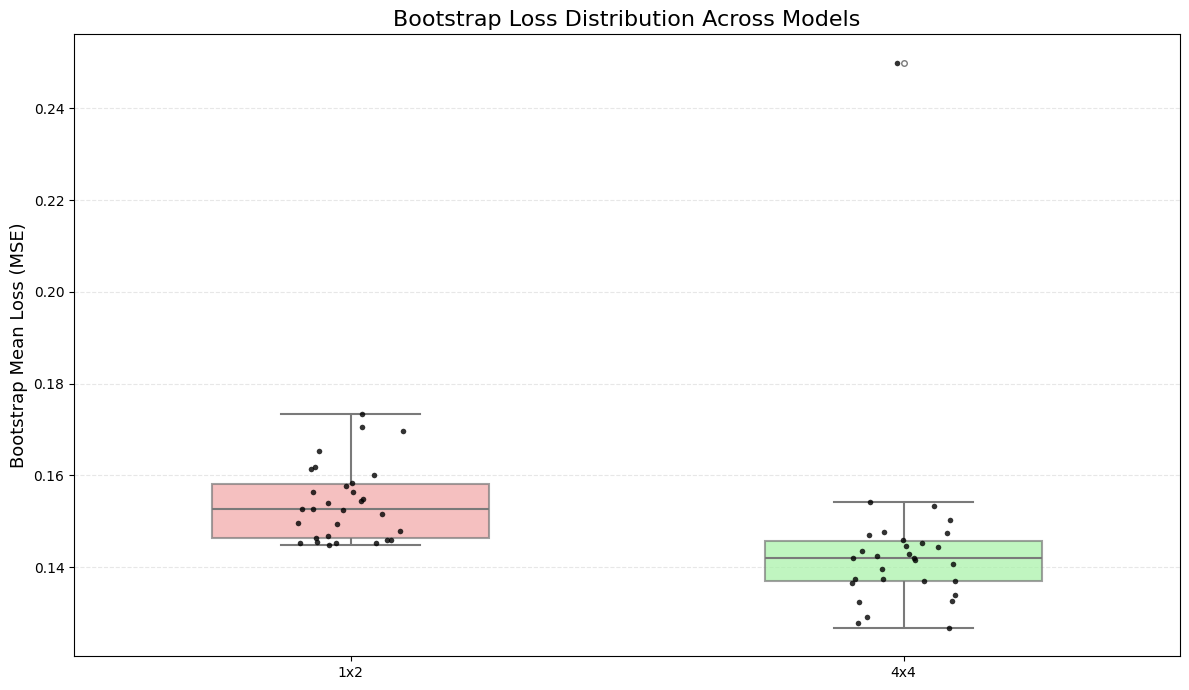

In [ ]:

df = pd.DataFrame({
    'Model': ['1x2']*30 + ['4x4']*30,
    'Error': losses_1x2 + losses_4x4
})

plt.figure(figsize=(12, 7))

palette = {
    '1x2': '#FF9999',   
    '4x4': '#99FF99'    
}

sns.boxplot(
    x='Model',
    y='Error',
    data=df,
    palette=palette,
    width=0.5,
    boxprops={'alpha': 0.7},
    showcaps=True,
    fliersize=4,
    linewidth=1.5
)

sns.stripplot(
    x='Model',
    y='Error',
    data=df,
    color='black',
    size=4,
    jitter=True,
    alpha=0.8
)

plt.title('Bootstrap Loss Distribution Across Models', fontsize=16)
plt.ylabel('Bootstrap Mean Loss (MSE)', fontsize=13)
plt.xlabel('')

plt.grid(True, axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


In [18]:
def analyze_bootstrap_results(losses_a, losses_b, name_a="1x2", name_b="4x4"):
    losses_a = np.array(losses_a)
    losses_b = np.array(losses_b)
    
    print(f"--- تحلیل توزیع خطا ---")
    print(f"مدل {name_a}: Mean={losses_a.mean():.4f}, Median={np.median(losses_a):.4f}")
    print(f"مدل {name_b}: Mean={losses_b.mean():.4f}, Median={np.median(losses_b):.4f}")
    
    ci_a = np.percentile(losses_a, [2.5, 97.5])
    ci_b = np.percentile(losses_b, [2.5, 97.5])
    print(f"\n--- فاصله اطمینان 95% ---")
    print(f"مدل {name_a}: [{ci_a[0]:.4f}, {ci_a[1]:.4f}]")
    print(f"مدل {name_b}: [{ci_b[0]:.4f}, {ci_b[1]:.4f}]")
    
    better_count = np.sum(losses_b < losses_a)
    prob_b_better = (better_count / len(losses_a)) * 100
    print(f"\n--- تحلیل مقایسه‌ای ---")
    # فارسی و انگلیسی به هم می ریخت مجبور شدم انگلیسی بنویسم 
    print(f"Probability that model {name_b} has lower error than model {name_a}: "
          f"{prob_b_better:.1f}%")

analyze_bootstrap_results(losses_1x2, losses_4x4)

--- تحلیل توزیع خطا ---
مدل 1x2: Mean=0.1541, Median=0.1527
مدل 4x4: Mean=0.1444, Median=0.1420

--- فاصله اطمینان 95% ---
مدل 1x2: [0.1451, 0.1714]
مدل 4x4: [0.1276, 0.1806]

--- تحلیل مقایسه‌ای ---
Probability that model 4x4 has lower error than model 1x2: 86.7%


# <div dir = 'rtl'>آزمایش تابع فعالسازی</div>

In [19]:
activations_to_test = ["relu", "sigmoid", "leakyrelu", "tanh"]
num_layers = 8       
num_neurons = 16      
epochs = 200          
lr = 0.001
results_1 = {}
for act_name in activations_to_test:
    print(f"Training model with {act_name}...")
    model = DynamicNet(num_layers, num_neurons, Xtr.shape[1], act_name).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(),lr=lr)
    
    train_losses_1 = []
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        logits = model(Xtr)
        loss = criterion (logits, ytr)
        loss.backward()
        optimizer.step()
        train_losses_1.append(loss.item())
    results_1[act_name] = train_losses_1
    print(f"Finished {act_name}. Final Loss: {train_losses_1[-1]:.4f}")

Training model with relu...
Finished relu. Final Loss: 0.3599
Training model with sigmoid...
Finished sigmoid. Final Loss: 0.6565
Training model with leakyrelu...
Finished leakyrelu. Final Loss: 0.3531
Training model with tanh...
Finished tanh. Final Loss: 0.3763


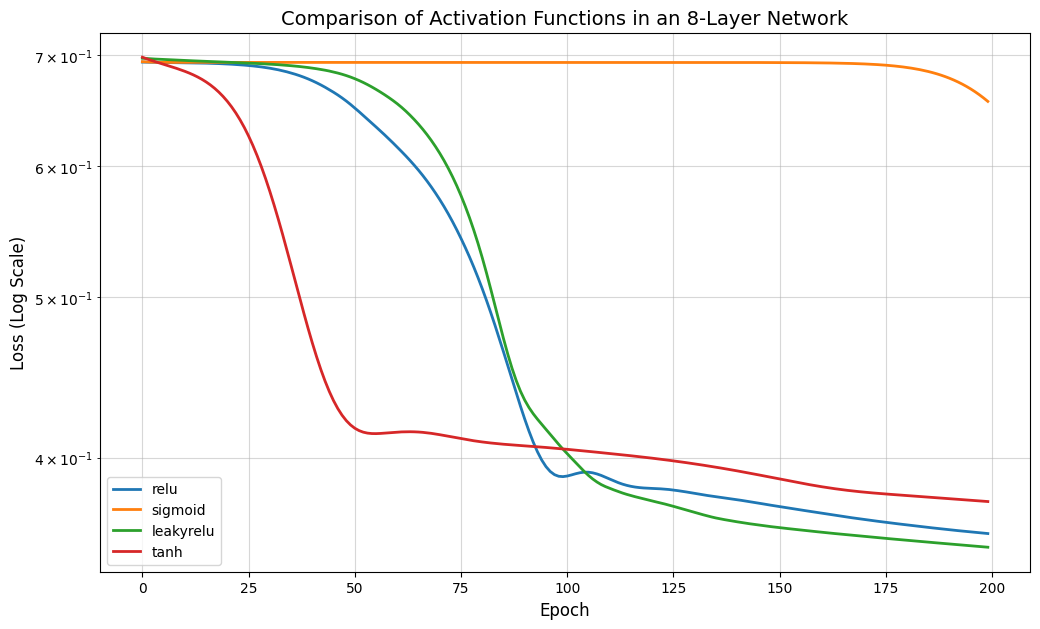

In [20]:
plt.figure(figsize=(12, 7))

for act_name, losses in results_1.items():
    plt.plot(losses, label=act_name, linewidth=2)

plt.yscale('log') # استفاده از مقیاس لگاریتمی برای دیدن بهتر جزئیات در Lossهای کوچک
plt.title("Comparison of Activation Functions in an 8-Layer Network", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss (Log Scale)", fontsize=12)
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()


In [21]:
def init_weights_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0.0)

activations_to_test = ["relu", "sigmoid", "leakyrelu", "tanh"]
num_layers = 8
num_neurons = 16
epochs = 200
lr = 0.001

Xtr = x_train.to(device)
ytr = y_train.view(-1, 1).to(device)

results_xavier = {}

for act_name in activations_to_test:
    print(f"Training model with {act_name} (Xavier Init)...")
    
    model = DynamicNet(num_layers, num_neurons, input_dim=Xtr.shape[1], activation=act_name).to(device)
    
    model.apply(init_weights_xavier)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        
        logits = model(Xtr)
        loss = criterion(logits, ytr)
        
        loss.backward()
        optimizer.step()
        
        train_losses.append(loss.item())
        
    results_xavier[act_name] = train_losses
    print(f"Finished {act_name}. Final Loss: {train_losses[-1]:.4f}")


Training model with relu (Xavier Init)...
Finished relu. Final Loss: 0.3572
Training model with sigmoid (Xavier Init)...
Finished sigmoid. Final Loss: 0.5957
Training model with leakyrelu (Xavier Init)...
Finished leakyrelu. Final Loss: 0.3569
Training model with tanh (Xavier Init)...
Finished tanh. Final Loss: 0.3629


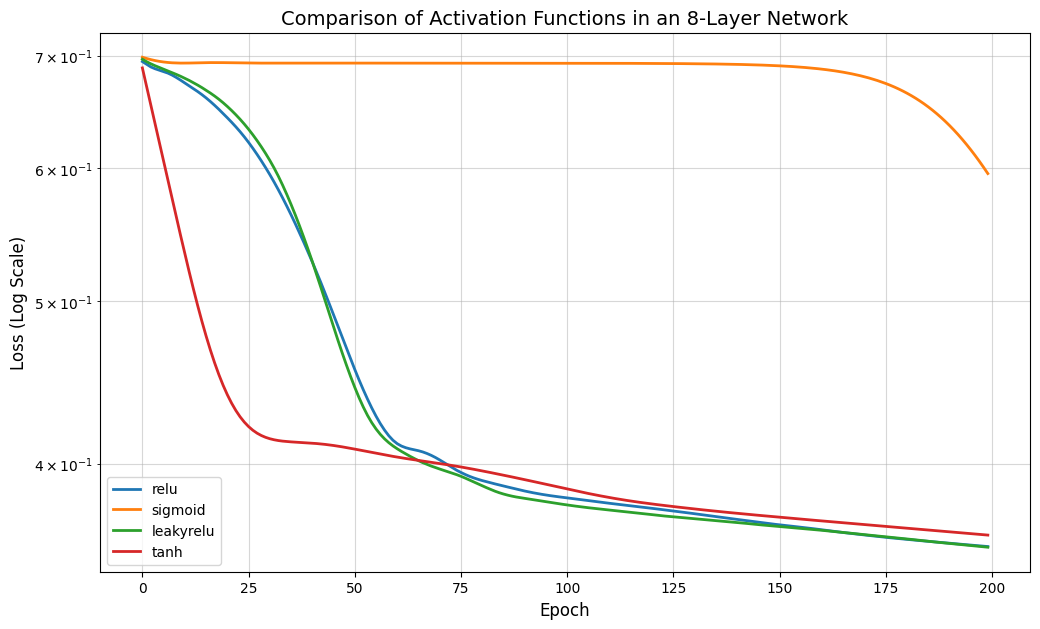

In [22]:
plt.figure(figsize=(12, 7))

for act_name, losses in results_xavier.items():
    plt.plot(losses, label=act_name, linewidth=2)

plt.yscale('log') # استفاده از مقیاس لگاریتمی برای دیدن بهتر جزئیات در Lossهای کوچک
plt.title("Comparison of Activation Functions in an 8-Layer Network", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss (Log Scale)", fontsize=12)
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()


# <div dir = 'rtl'>آزمایش منظم سازی</div>

In [ ]:
def train_model(dropout_rate=0.0, l2_lambda=0.0, epochs=200, lr=0.001):
    
    model = DynamicNet(
        num_layers=8,
        num_neurons=128,
        input_dim=Xtr.shape[1],
        activation="relu",
        dropout_rate=dropout_rate
    ).to(device)
    
        
    criterion = nn.BCEWithLogitsLoss()
    
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=l2_lambda)
    
    
    
    Xval = x_test.to(device)
    yval = y_test.view(-1,1).to(device)
    
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        
        
        model.train()   
        
        optimizer.zero_grad()
        
        logits = model(Xtr)
        train_loss = criterion(logits, ytr)
        
        train_loss.backward()
        optimizer.step()
        
        train_losses.append(train_loss.item())
        
        
        
        model.eval()   
        
        with torch.no_grad():
            val_logits = model(Xval)
            val_loss = criterion(val_logits, yval)
            
        val_losses.append(val_loss.item())
        
        
        if (epoch+1) % 20 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] "
                  f"Train Loss: {train_loss.item():.4f} | "
                  f"Val Loss: {val_loss.item():.4f}")
    
    return train_losses, val_losses

In [24]:
experiments = [
    {"dropout": 0.0, "l2": 0.0},
    {"dropout": 0.2, "l2": 0.0},
    {"dropout": 0.5, "l2": 0.0},
    {"dropout": 0.0, "l2": 1e-4},
    {"dropout": 0.2, "l2": 1e-4},
]

results = {}

for exp in experiments:
    print(f"\nRunning: Dropout={exp['dropout']} | L2={exp['l2']}")
    
    train_l, val_l = train_model(
        dropout_rate=exp["dropout"],
        l2_lambda=exp["l2"],
        epochs=200
    )
    
    key = f"Dropout={exp['dropout']}, L2={exp['l2']}"
    results[key] = (train_l, val_l)



Running: Dropout=0.0 | L2=0.0
Epoch [20/200] Train Loss: 0.4247 | Val Loss: 0.5007
Epoch [40/200] Train Loss: 0.3888 | Val Loss: 0.4484
Epoch [60/200] Train Loss: 0.3662 | Val Loss: 0.4162
Epoch [80/200] Train Loss: 0.3528 | Val Loss: 0.4074
Epoch [100/200] Train Loss: 0.3453 | Val Loss: 0.3928
Epoch [120/200] Train Loss: 0.3324 | Val Loss: 0.3766
Epoch [140/200] Train Loss: 0.3267 | Val Loss: 0.3743
Epoch [160/200] Train Loss: 0.3233 | Val Loss: 0.3737
Epoch [180/200] Train Loss: 0.3201 | Val Loss: 0.3739
Epoch [200/200] Train Loss: 0.3181 | Val Loss: 0.3742

Running: Dropout=0.2 | L2=0.0
Epoch [20/200] Train Loss: 0.4605 | Val Loss: 0.5286
Epoch [40/200] Train Loss: 0.3964 | Val Loss: 0.4441
Epoch [60/200] Train Loss: 0.3810 | Val Loss: 0.4241
Epoch [80/200] Train Loss: 0.3733 | Val Loss: 0.4152
Epoch [100/200] Train Loss: 0.3679 | Val Loss: 0.4057
Epoch [120/200] Train Loss: 0.3592 | Val Loss: 0.3976
Epoch [140/200] Train Loss: 0.3510 | Val Loss: 0.3931
Epoch [160/200] Train Loss: 

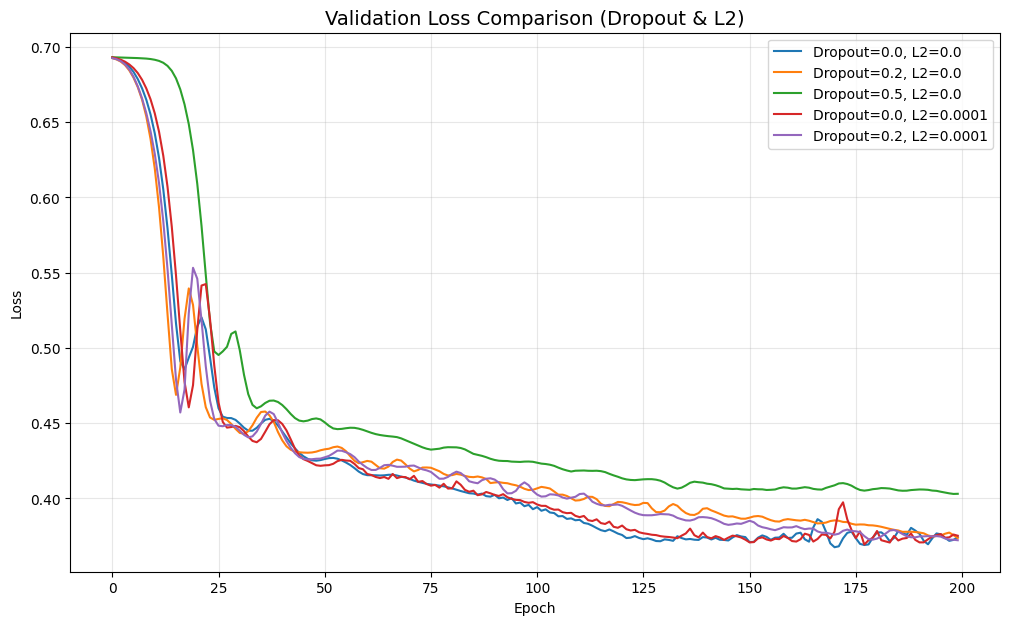

In [25]:

plt.figure(figsize=(12,7))

for key, (train_l, val_l) in results.items():
    plt.plot(val_l, label=key)

plt.title("Validation Loss Comparison (Dropout & L2)", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [26]:
class LRNet(nn.Module):
    def __init__(self, input_dim, activation="relu"):
        super(LRNet, self).__init__()
        
        activations = {
            "relu": nn.ReLU(),
            "leakyrelu": nn.LeakyReLU(),
            "tanh": nn.Tanh()
        }
        act = activations[activation.lower()]
        
        layers = []
        current_dim = input_dim
        
        for _ in range(8):
            layers.append(nn.Linear(current_dim, 64))
            layers.append(act)
            current_dim = 64
        
        layers.append(nn.Linear(64, 1))
        
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x)


In [ ]:
def train_with_lr(lr, batch_size, optimizer_type="sgd", epochs=100):
    
    model = LRNet(input_dim=Xte.shape[1]).to(device)
    model.apply(init_weights_xavier)
    
    criterion = nn.BCEWithLogitsLoss()
    
    if optimizer_type == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    dataset = torch.utils.data.TensorDataset(x_train, y_train.view(-1,1))
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    val_x = x_test.to(device)
    val_y = y_test.view(-1,1).to(device)
    
    val_losses = []
    
    for epoch in range(epochs):
        
        model.train()
        
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
        
        model.eval()
        with torch.no_grad():
            val_logits = model(val_x)
            val_loss = criterion(val_logits, val_y)
        
        val_losses.append(val_loss.item())
        
        if (epoch+1) % 20 == 0:
            print(f"[{optimizer_type.upper()}] LR={lr}, BS={batch_size}, Epoch {epoch+1:03d}: Val Loss={val_loss.item():.4f}")
    
    return val_losses


In [28]:
learning_rates = [0.1, 0.01, 0.001]
results_lr = {}

for lr in learning_rates:
    losses = train_with_lr(lr=lr, batch_size=128, optimizer_type="sgd")
    results_lr[f"LR={lr}"] = losses


[SGD] LR=0.1, BS=128, Epoch 020: Val Loss=0.4056
[SGD] LR=0.1, BS=128, Epoch 040: Val Loss=0.4103
[SGD] LR=0.1, BS=128, Epoch 060: Val Loss=0.3836
[SGD] LR=0.1, BS=128, Epoch 080: Val Loss=0.3794
[SGD] LR=0.1, BS=128, Epoch 100: Val Loss=0.3813
[SGD] LR=0.01, BS=128, Epoch 020: Val Loss=0.6163
[SGD] LR=0.01, BS=128, Epoch 040: Val Loss=0.4463
[SGD] LR=0.01, BS=128, Epoch 060: Val Loss=0.4295
[SGD] LR=0.01, BS=128, Epoch 080: Val Loss=0.4214
[SGD] LR=0.01, BS=128, Epoch 100: Val Loss=0.4175
[SGD] LR=0.001, BS=128, Epoch 020: Val Loss=0.6849
[SGD] LR=0.001, BS=128, Epoch 040: Val Loss=0.6793
[SGD] LR=0.001, BS=128, Epoch 060: Val Loss=0.6725
[SGD] LR=0.001, BS=128, Epoch 080: Val Loss=0.6633
[SGD] LR=0.001, BS=128, Epoch 100: Val Loss=0.6512


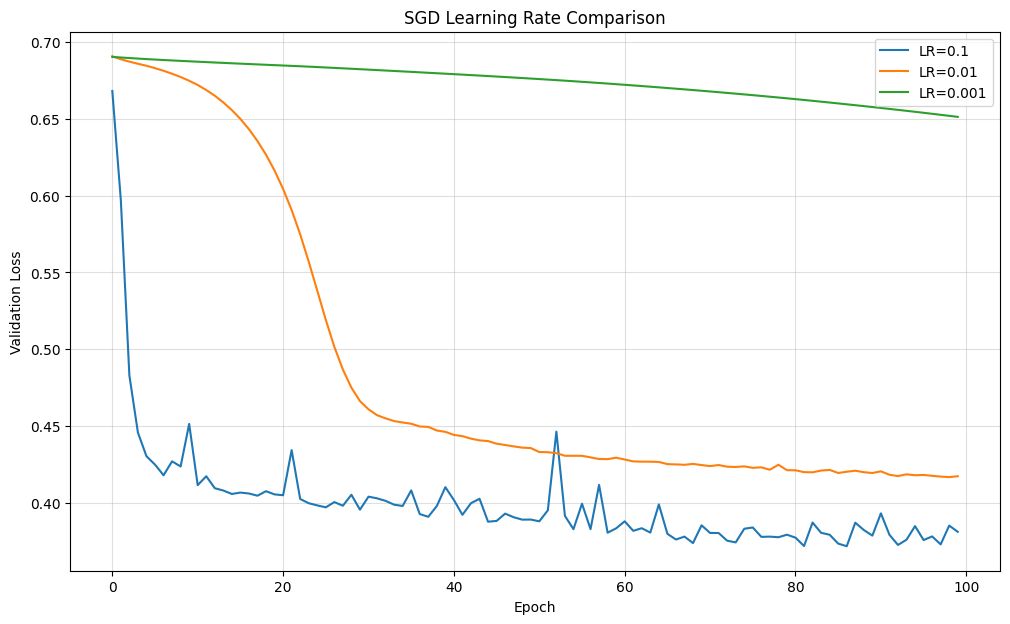

In [29]:
plt.figure(figsize=(12,7))

for key, loss in results_lr.items():
    plt.plot(loss, label=key)

plt.title("SGD Learning Rate Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()


In [30]:
batch_sizes = [32, 128, 256]
results_bs = {}

for bs in batch_sizes:
    losses = train_with_lr(lr=0.01, batch_size=bs, optimizer_type="sgd")
    results_bs[f"BS={bs}"] = losses


[SGD] LR=0.01, BS=32, Epoch 020: Val Loss=0.4194
[SGD] LR=0.01, BS=32, Epoch 040: Val Loss=0.4094
[SGD] LR=0.01, BS=32, Epoch 060: Val Loss=0.4031
[SGD] LR=0.01, BS=32, Epoch 080: Val Loss=0.3975
[SGD] LR=0.01, BS=32, Epoch 100: Val Loss=0.3947
[SGD] LR=0.01, BS=128, Epoch 020: Val Loss=0.5180
[SGD] LR=0.01, BS=128, Epoch 040: Val Loss=0.4467
[SGD] LR=0.01, BS=128, Epoch 060: Val Loss=0.4281
[SGD] LR=0.01, BS=128, Epoch 080: Val Loss=0.4202
[SGD] LR=0.01, BS=128, Epoch 100: Val Loss=0.4155
[SGD] LR=0.01, BS=256, Epoch 020: Val Loss=0.6757
[SGD] LR=0.01, BS=256, Epoch 040: Val Loss=0.6310
[SGD] LR=0.01, BS=256, Epoch 060: Val Loss=0.5075
[SGD] LR=0.01, BS=256, Epoch 080: Val Loss=0.4484
[SGD] LR=0.01, BS=256, Epoch 100: Val Loss=0.4382


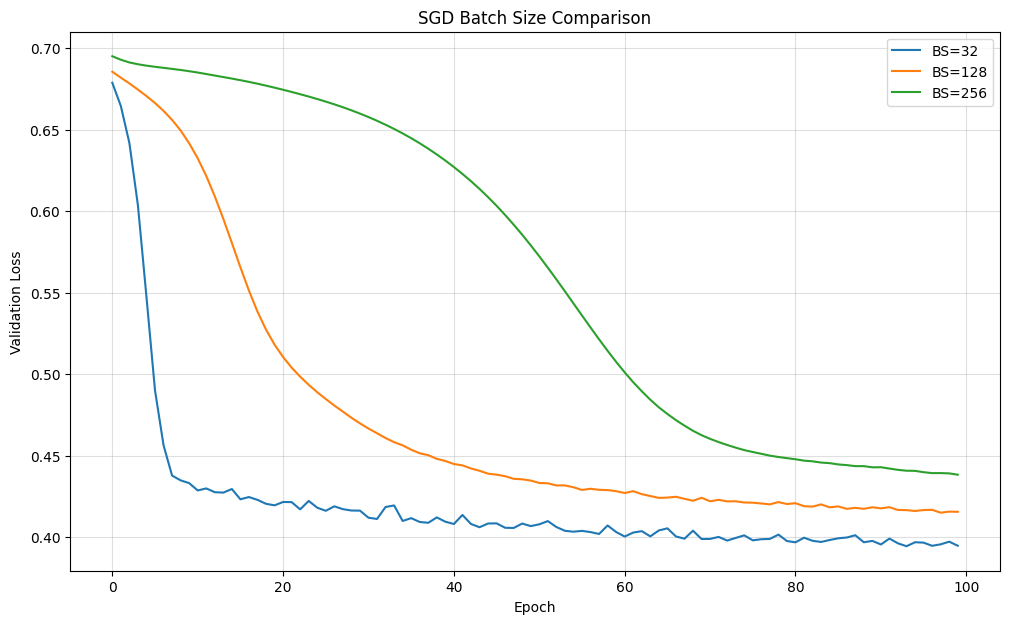

In [31]:
plt.figure(figsize=(12,7))

for key, loss in results_bs.items():
    plt.plot(loss, label=key)

plt.title("SGD Batch Size Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()


[ADAM] LR=0.001, BS=128, Epoch 020: Val Loss=0.3926
[ADAM] LR=0.001, BS=128, Epoch 040: Val Loss=0.3866
[ADAM] LR=0.001, BS=128, Epoch 060: Val Loss=0.3727
[ADAM] LR=0.001, BS=128, Epoch 080: Val Loss=0.3750
[ADAM] LR=0.001, BS=128, Epoch 100: Val Loss=0.3823
[SGD] LR=0.001, BS=128, Epoch 020: Val Loss=0.6901
[SGD] LR=0.001, BS=128, Epoch 040: Val Loss=0.6879
[SGD] LR=0.001, BS=128, Epoch 060: Val Loss=0.6854
[SGD] LR=0.001, BS=128, Epoch 080: Val Loss=0.6818
[SGD] LR=0.001, BS=128, Epoch 100: Val Loss=0.6761


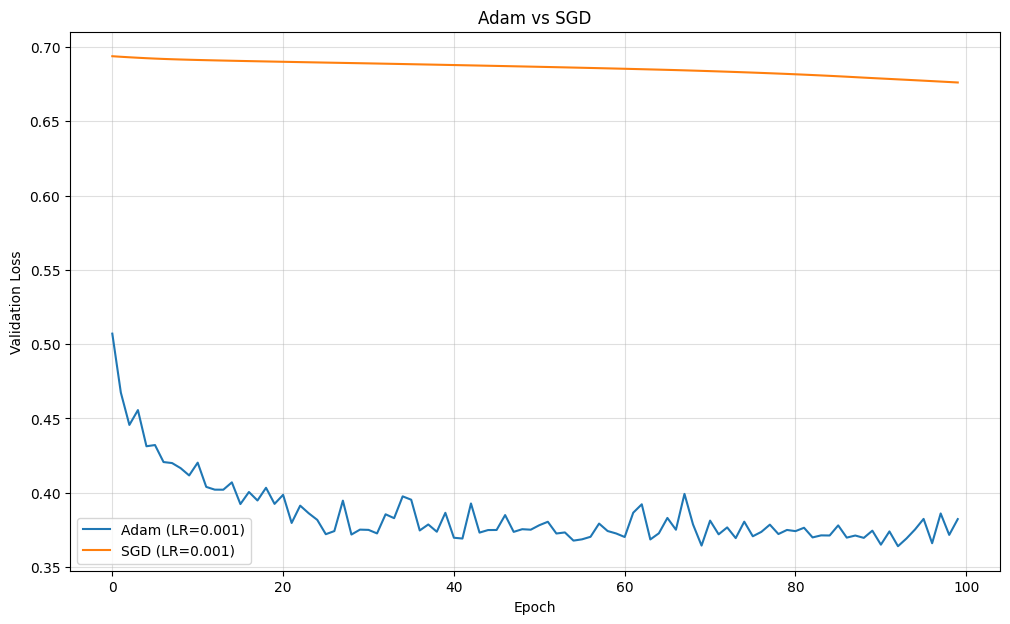

In [32]:
adam_loss = train_with_lr(lr=0.001, batch_size=128, optimizer_type="adam")
sgd_loss  = train_with_lr(lr=0.001, batch_size=128, optimizer_type="sgd")

plt.figure(figsize=(12,7))
plt.plot(adam_loss, label="Adam (LR=0.001)")
plt.plot(sgd_loss, label="SGD (LR=0.001)")
plt.title("Adam vs SGD")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()


# <div dir = 'rtl'>بخش دوم: مجموعه داده های واقعی </div>

In [33]:
CSV_PATH = "covtype.csv"      
TEST_SIZE = 0.2
RANDOM_STATE = 42

BATCH_SIZE = 4096             
EPOCHS = 25                   
LR = 1e-3
WEIGHT_DECAY = 1e-4           
USE_AMP = False                

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [34]:
df = pd.read_csv(CSV_PATH)
y_1 = df.iloc[:, -1].values
X_1 = df.iloc[:, :-1].values

In [35]:
y_1 = y_1.astype(np.int64)
if y_1.min() == 1:
    y_1 = y_1 - 1

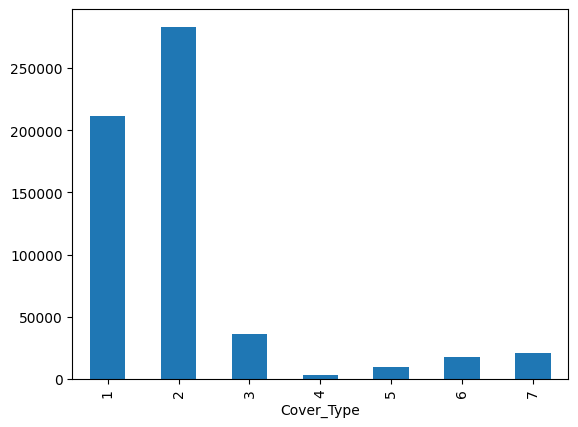

In [48]:
df['Cover_Type'].value_counts().sort_index().plot(kind='bar');

In [ ]:
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(
    X_1, y_1, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_1
)

In [ ]:
scaler = StandardScaler()
X_train_1 = scaler.fit_transform(X_train_1)
X_test_1  = scaler.transform(X_test_1)

In [ ]:
X_train_t = torch.tensor(X_train_1, dtype=torch.float32)
y_train_t = torch.tensor(y_train_1, dtype=torch.long)
X_test_t  = torch.tensor(X_test_1, dtype=torch.float32)
y_test_t  = torch.tensor(y_test_1, dtype=torch.long)

In [ ]:
train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=(device.type == "cuda"),
    persistent_workers=True if device.type == "cuda" else False)

In [ ]:
test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == "cuda"),
    persistent_workers=True if device.type == "cuda" else False)

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, num_classes=7, dropout=0.0):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [ ]:
def accuracy_from_logits(logits, y):
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds = []
    all_true = []
    total_loss = 0.0
    total_n = 0
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        logits = model(xb)
        loss = F.cross_entropy(logits, yb, reduction="sum")

        total_loss += loss.item()
        total_n += yb.size(0)

        preds = logits.argmax(dim=1)
        all_preds.append(preds.detach().cpu().numpy())
        all_true.append(yb.detach().cpu().numpy())

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_preds)

    avg_loss = total_loss / total_n
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    acc = (y_true == y_pred).mean()

    return avg_loss, macro_f1, acc, y_true, y_pred

In [ ]:
def train_model(model, train_loader, test_loader, epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    scaler_amp = torch.amp.GradScaler(enabled=(USE_AMP and device.type == "cuda"))

    hist = {
        "train_loss": [],
        "test_loss": [],
        "test_macro_f1": [],
        "test_acc": []
    }

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        n_seen = 0

        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast(device_type="cuda", enabled=(USE_AMP and device.type == "cuda")):
                logits = model(xb)
                loss = F.cross_entropy(logits, yb)

            scaler_amp.scale(loss).backward()
            scaler_amp.step(optimizer)
            scaler_amp.update()

            running_loss += loss.item() * yb.size(0)
            n_seen += yb.size(0)

        train_loss = running_loss / n_seen
        test_loss, test_f1, test_acc, _, _ = evaluate(model, test_loader)

        hist["train_loss"].append(train_loss)
        hist["test_loss"].append(test_loss)
        hist["test_macro_f1"].append(test_f1)
        hist["test_acc"].append(test_acc)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"TrainLoss={train_loss:.4f} | TestLoss={test_loss:.4f} | "
            f"MacroF1={test_f1:.4f} | Acc={test_acc:.4f}"
        )

    return model, hist

In [ ]:
input_dim = X_train_1.shape[1]
num_classes = 7

model_small = MLP(input_dim, hidden_dims=[128, 64], num_classes=num_classes, dropout=0.1)
model_big   = MLP(input_dim, hidden_dims=[512, 256, 128, 64], num_classes=num_classes, dropout=0.2)

print("\nTraining SMALL model...")
model_small_trained, hist_small = train_model(model_small, train_loader, test_loader)

print("\nTraining BIG model...")
model_big_trained, hist_big = train_model(model_big, train_loader, test_loader)



Training SMALL model...
Epoch 01/25 | TrainLoss=0.9890 | TestLoss=0.6796 | MacroF1=0.4093 | Acc=0.7247
Epoch 02/25 | TrainLoss=0.6621 | TestLoss=0.6209 | MacroF1=0.4303 | Acc=0.7393
Epoch 03/25 | TrainLoss=0.6220 | TestLoss=0.5892 | MacroF1=0.5309 | Acc=0.7508
Epoch 04/25 | TrainLoss=0.5956 | TestLoss=0.5637 | MacroF1=0.5732 | Acc=0.7605
Epoch 05/25 | TrainLoss=0.5730 | TestLoss=0.5408 | MacroF1=0.5518 | Acc=0.7694
Epoch 06/25 | TrainLoss=0.5552 | TestLoss=0.5233 | MacroF1=0.6201 | Acc=0.7785
Epoch 07/25 | TrainLoss=0.5393 | TestLoss=0.5085 | MacroF1=0.6390 | Acc=0.7834
Epoch 08/25 | TrainLoss=0.5257 | TestLoss=0.4936 | MacroF1=0.6424 | Acc=0.7887
Epoch 09/25 | TrainLoss=0.5148 | TestLoss=0.4801 | MacroF1=0.6434 | Acc=0.7939
Epoch 10/25 | TrainLoss=0.5038 | TestLoss=0.4700 | MacroF1=0.6566 | Acc=0.7979
Epoch 11/25 | TrainLoss=0.4964 | TestLoss=0.4613 | MacroF1=0.6772 | Acc=0.8021
Epoch 12/25 | TrainLoss=0.4886 | TestLoss=0.4531 | MacroF1=0.6751 | Acc=0.8046
Epoch 13/25 | TrainLoss=0.4

In [ ]:
test_loss_s, f1_s, acc_s, y_true_s, y_pred_s = evaluate(model_small_trained, test_loader)
test_loss_b, f1_b, acc_b, y_true_b, y_pred_b = evaluate(model_big_trained, test_loader)

print("\n=== SMALL MODEL REPORT ===")
print(f"TestLoss={test_loss_s:.4f} | MacroF1={f1_s:.4f} | Acc={acc_s:.4f}")
print(classification_report(y_true_s, y_pred_s, digits=4))

print("\n=== BIG MODEL REPORT ===")
print(f"TestLoss={test_loss_b:.4f} | MacroF1={f1_b:.4f} | Acc={acc_b:.4f}")
print(classification_report(y_true_b, y_pred_b, digits=4))


=== SMALL MODEL REPORT ===
TestLoss=0.3861 | MacroF1=0.7427 | Acc=0.8400
              precision    recall  f1-score   support

           0     0.8450    0.8243    0.8345     42368
           1     0.8486    0.8856    0.8667     56661
           2     0.8007    0.8526    0.8258      7151
           3     0.8153    0.6029    0.6932       549
           4     0.7385    0.3734    0.4960      1899
           5     0.6715    0.6133    0.6411      3473
           6     0.9011    0.7889    0.8413      4102

    accuracy                         0.8400    116203
   macro avg     0.8030    0.7059    0.7427    116203
weighted avg     0.8390    0.8400    0.8380    116203


=== BIG MODEL REPORT ===
TestLoss=0.2410 | MacroF1=0.8517 | Acc=0.9048
              precision    recall  f1-score   support

           0     0.9185    0.8832    0.9005     42368
           1     0.9061    0.9351    0.9204     56661
           2     0.8787    0.9178    0.8978      7151
           3     0.8209    0.7596    0.7

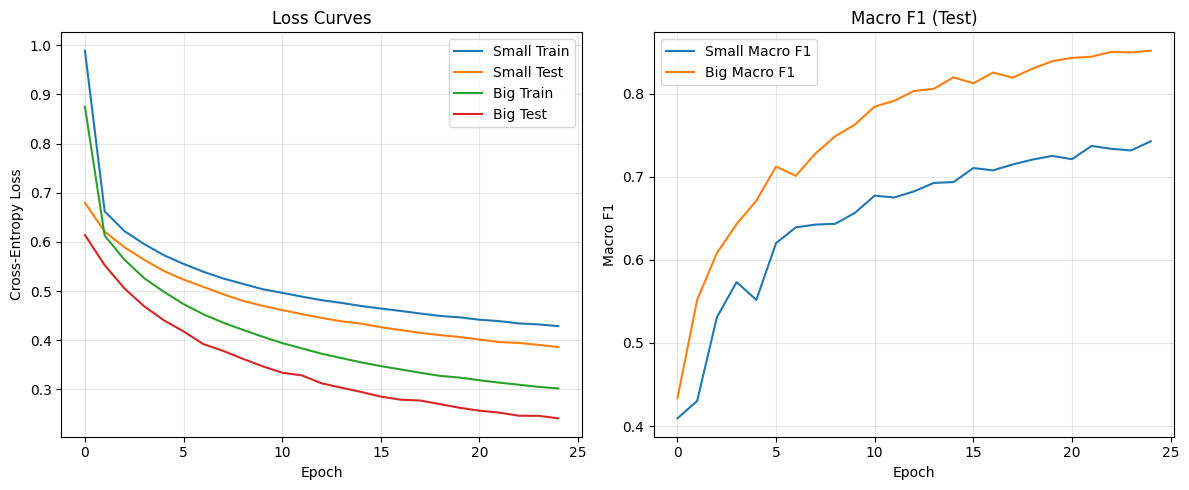

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(hist_small["train_loss"], label="Small Train")
plt.plot(hist_small["test_loss"], label="Small Test")
plt.plot(hist_big["train_loss"], label="Big Train")
plt.plot(hist_big["test_loss"], label="Big Test")
plt.title("Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1,2,2)
plt.plot(hist_small["test_macro_f1"], label="Small Macro F1")
plt.plot(hist_big["test_macro_f1"], label="Big Macro F1")
plt.title("Macro F1 (Test)")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()